In [1]:
%load_ext autoreload
%autoreload 2

# %%

from pathlib import Path
from datetime import datetime
import sys
import matplotlib.pyplot as plt
import pandas as pd

current_dir = Path(".")

# %% create folders and make path
msmt_code_path = Path(r"../../..").resolve()
experiment_path = Path("..").resolve().parent
src_path = msmt_code_path / "src"
driver_path = msmt_code_path / "drivers"
instr_path = driver_path / "instruments"

all_paths = [current_dir, experiment_path, msmt_code_path, src_path, driver_path, instr_path]

# make sure all paths exist, then append to $PATH
for path in all_paths:
    path = path.resolve()  # convert relative Path objs to absolutes
    print(f"Checking if path exists:  ['{path}']")
    print(f"     {str(path.exists()).upper()}")
    sys.path.append(str(path))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Checking if path exists:  ['C:\Users\Lehnert Lab\GitHub\bcqt-ctrl\prototype_msmt_code\experiments\VNA Experiments\VNA Characterization']
     TRUE
Checking if path exists:  ['C:\Users\Lehnert Lab\GitHub\bcqt-ctrl\prototype_msmt_code\experiments']
     TRUE
Checking if path exists:  ['C:\Users\Lehnert Lab\GitHub\bcqt-ctrl\prototype_msmt_code']
     TRUE
Checking if path exists:  ['C:\Users\Lehnert Lab\GitHub\bcqt-ctrl\prototype_msmt_code\src']
     TRUE
Checking if path exists:  ['C:\Users\Lehnert Lab\GitHub\bcqt-ctrl\prototype_msmt_code\drivers']
     TRUE
Checking if path exists:  ['C:\Users\Lehnert Lab\GitHub\bcqt-ctrl\prototype_msmt_code\drivers\instruments']
     TRUE


In [2]:
def Load_CSV(filepath):
    """
        convenience method - take csv filepath and return df, magns, phases, and freqs
    """
    
    if not isinstance(filepath, Path):
        filepath = Path(filepath).absolute()
    
    df = pd.read_csv(filepath, index_col=0)
    
    all_magns, all_phases = [], []
    
    for col in df:
        if "magn" in col.lower():
            series = df[col].values[1:].astype(float)
            all_magns.append(series)
        if "phase" in col.lower():
            series = df[col].values[1:].astype(float)
            all_phases.append(series)
        if "freq" in col.lower():
            freqs = df[col].values[1:].astype(float)
    
    return df, all_magns, all_phases, freqs


In [3]:
import quick_helpers as qh

data_path = current_dir / "data"
# S21_MXC = data_path / "S21_MXC"
# S12_MXC = data_path / "S12_MXC"

HEMT_A = data_path / "HEMT_A_ON"
HEMT_B = data_path / "HEMT_B_ON"
RT_A = data_path / "RT_Ampl_A"
RT_B = data_path / "RT_Ampl_B"

plot_dict_base = {
        "plot_complex" : False,
        "do_edelay_fit" : False,
        "track_min" : False,
        "suptitle" : None,
        "magn_color" : 'r',
        "phase_color" : 'b',
        "magn_label" : None,
        "phase_label" : None,
        "do_legend" : True,
}


### Input line 23 to output 27, so S21 measurement



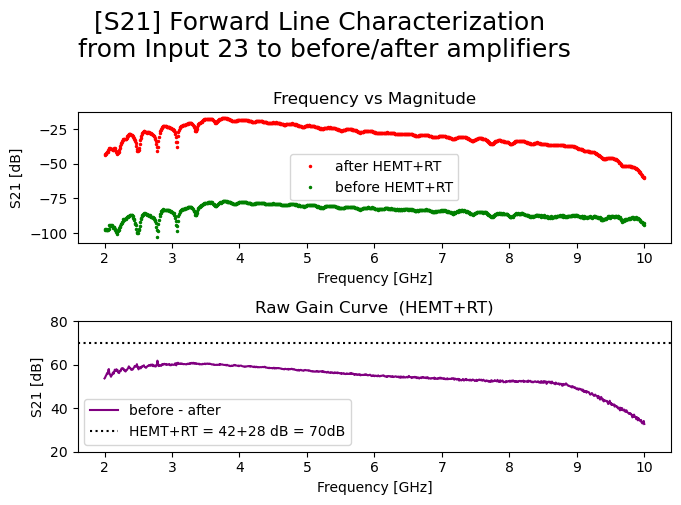

In [ ]:
Line23_beforeHEMT_dir = list(S21_MXC.glob("009*"))[0]
Line23_afterHEMT_dir = list(S21_MXC.glob("010*"))[0]

Line23_beforeHEMT = list(Line23_beforeHEMT_dir.glob("*.csv"))[0]
Line23_afterHEMT = list(Line23_afterHEMT_dir.glob("*.csv"))[0]

all_dfs = {}
prev_axes = None
for csv_file in [Line23_afterHEMT, Line23_beforeHEMT]:
    meas_name = csv_file.name
    loaded_df, all_magns, all_phases, freqs = Load_CSV(csv_file)
    plot_dict = plot_dict_base
    plot_dict["suptitle"] = meas_name
    
    assert len(all_magns) == 1
    
    magn_dB = all_magns[0]
    phase_rad = all_phases[0]
    
    if prev_axes is None:
        # plot #1
        plot_dict["magn_color"] = 'r'
        plot_dict["phase_color"] = 'r'
        plot_dict["magn_label"] = "after HEMT+RT"
        plot_dict["phase_label"] = "after HEMT+RT"
        axes = qh.plot_data_with_pandas(freqs=freqs, magn_dB=magn_dB, phase_rad=phase_rad, axes=prev_axes, plot_dict=plot_dict)
        prev_axes = axes
    else:
        # plot #2
        plot_dict["magn_color"] = 'g'
        plot_dict["phase_color"] = 'g'
        plot_dict["magn_label"] = "before HEMT+RT"
        plot_dict["phase_label"] = "before HEMT+RT"
        axes = qh.plot_data_with_pandas(freqs=freqs, magn_dB=magn_dB, phase_rad=phase_rad, axes=prev_axes, plot_dict=plot_dict)
        prev_axes = axes
        
    all_dfs[meas_name] = loaded_df


fig = axes[0].get_figure()
ax1, ax2 = axes
ax2.clear()
    
lines = ax1.get_lines()
after_hemt, before_hemt = lines[0].get_ydata(), lines[1].get_ydata()
diff = after_hemt - before_hemt

ax2.plot(freqs/1e9, diff, color='purple', label="before - after")
ax2.set_title("Raw Gain Curve  (HEMT+RT)")
ax2.axhline(70, label="HEMT+RT = 42+28 dB = 70dB", linestyle=':', color='k')

ax2.set_ylabel("S21 [dB]")
ax2.set_xlabel("Frequency [GHz]")
ax2.set_ylim([20, 80])
ax2.legend()

fig.suptitle(t="[S21] Forward Line Characterization\n from Input 23 to before/after amplifiers", x=0.25, y=1.0, fontsize=18)
fig.tight_layout()


### copy pasted but now for S12 measurement

[55.39715767 55.96957588 55.88483238 ... 27.67051315 28.64045715
 27.60785675]


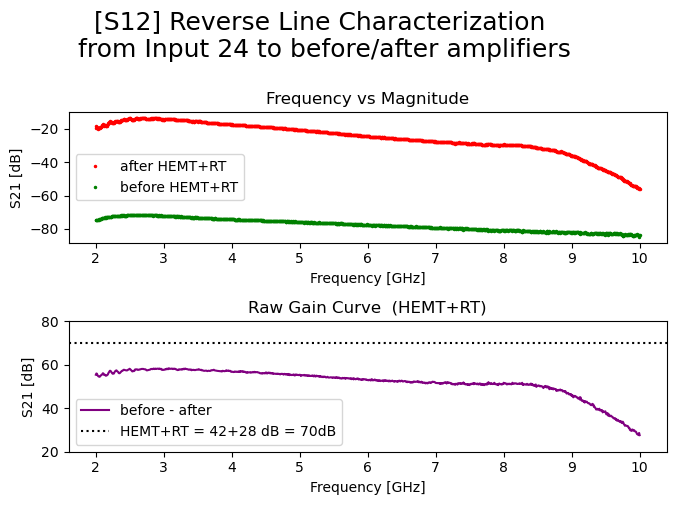

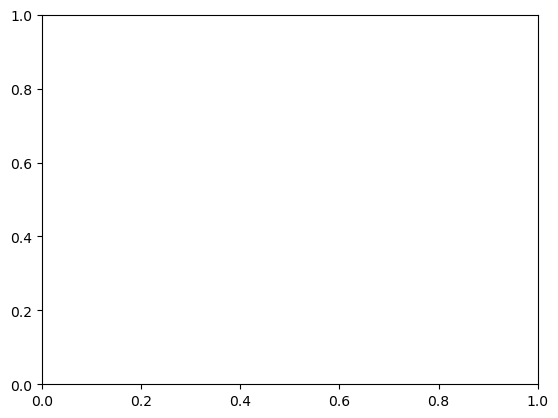

In [ ]:
Line24_beforeHEMT_dir = list(S12_MXC.glob("003*"))[0]
Line24_afterHEMT_dir = list(S12_MXC.glob("004*"))[0]

Line24_beforeHEMT = list(Line24_beforeHEMT_dir.glob("*.csv"))[0]
Line24_afterHEMT = list(Line24_afterHEMT_dir.glob("*.csv"))[0]

all_dfs = {}
prev_axes = None
for csv_file in [Line24_afterHEMT, Line24_beforeHEMT]:
    meas_name = csv_file.name
    loaded_df, all_magns, all_phases, freqs = Load_CSV(csv_file)
    plot_dict = plot_dict_base
    plot_dict["suptitle"] = meas_name
    
    assert len(all_magns) == 1
    
    magn_dB = all_magns[0]
    phase_rad = all_phases[0]
    
    if prev_axes is None:
        # plot #1
        plot_dict["magn_color"] = 'r'
        plot_dict["phase_color"] = 'r'
        plot_dict["magn_label"] = "after HEMT+RT"
        plot_dict["phase_label"] = "after HEMT+RT"
        axes = qh.plot_data_with_pandas(freqs=freqs, magn_dB=magn_dB, phase_rad=phase_rad, axes=prev_axes, plot_dict=plot_dict)
        prev_axes = axes
    else:
        # plot #2
        plot_dict["magn_color"] = 'g'
        plot_dict["phase_color"] = 'g'
        plot_dict["magn_label"] = "before HEMT+RT"
        plot_dict["phase_label"] = "before HEMT+RT"
        axes = qh.plot_data_with_pandas(freqs=freqs, magn_dB=magn_dB, phase_rad=phase_rad, axes=prev_axes, plot_dict=plot_dict)
        prev_axes = axes
        
    all_dfs[meas_name] = loaded_df


fig = axes[0].get_figure()
ax1, ax2 = axes
ax2.clear()
    
lines = ax1.get_lines()

after_hemt, before_hemt = lines[0].get_ydata(), lines[1].get_ydata()
diff = after_hemt - before_hemt

ax2.plot(freqs/1e9, diff, color='purple', label="before - after")
ax2.set_title("Raw Gain Curve  (HEMT+RT)")
ax2.axhline(70, label="HEMT+RT = 42+28 dB = 70dB", linestyle=':', color='k')

ax2.set_ylabel("S21 [dB]")
ax2.set_xlabel("Frequency [GHz]")
ax2.set_ylim([20, 80])
ax2.legend()

fig.suptitle(t="[S12] Reverse Line Characterization\n from Input 24 to before/after amplifiers", x=0.25, y=1.0, fontsize=18)
fig.tight_layout()


fig, axes = plt.subplots(2,1)
ax1, ax2 = axes
ax1.plot(freqs, after_hemt - 70)
ax2.plot(freqs, before_hemt - 70)

for ax in axes:
    ax2.axhline(0, linestyle=':', color='k')